## <span style="color:grey; font-weight:bold;">Import Data</span>

In [3]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)

In [4]:
import os

data_path = '/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis/Data'
os.chdir(data_path)

files = os.listdir()
print(files)

['train.txt', 'Objective Removed Duplicates Date.csv', 'cleaned_numerical_df.csv', 'readme.txt', 'test.txt', 'Numerical Removed Duplicates Date.csv']


In [ ]:
# 讀取訓練集和驗證集
df_train = pd.read_csv('train.txt', sep='\t')

## <span style="color:grey; font-weight:bold;">Exploratory Data Analysis</span>

### <span style="color:grey; font-weight:bold;">Descriptive Stats</span>

In [7]:
df_train.head()

,0,1,1.1,5,0.1,1382,4,15,2,181,...,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,Unnamed: 35,3a171ecb,c5c50484,e8b83407,9727dd16
0,0,2.000,0,44.000,1.000,102.000,8.000,2.000,2.000,4.000,...,07c540c4,b04e4670,21ddcdc9,5840adea,60f6221e,NaN,3a171ecb,43f13e8b,e8b83407,731c3655
1,0,2.000,0,1.000,14.000,767.000,89.000,4.000,2.000,245.000,...,8efede7f,3412118d,NaN,NaN,e587c466,ad3062eb,3a171ecb,3b183c5c,NaN,NaN
2,0,NaN,893,NaN,NaN,4392.000,NaN,0.000,0.000,0.000,...,1e88c74f,74ef3502,NaN,NaN,6b3a5ca6,NaN,3a171ecb,9117a34a,NaN,NaN
3,0,3.000,-1,NaN,0.000,2.000,0.000,3.000,0.000,0.000,...,1e88c74f,26b3c7a7,NaN,NaN,21c9516a,NaN,32c7478e,b34f3128,NaN,NaN
4,0,NaN,-1,NaN,NaN,12824.000,NaN,0.000,0.000,6.000,...,776ce399,92555263,NaN,NaN,242bb710,8ec974f4,be7c41b4,72c78f11,NaN,NaN


In [8]:
df_train.tail()

,0,1,1.1,5,0.1,1382,4,15,2,181,...,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,Unnamed: 35,3a171ecb,c5c50484,e8b83407,9727dd16
45840611,0,NaN,-1,NaN,NaN,34722.000,38.000,1.000,0.000,41.000,...,3486227d,891589e7,1d1eb838,a458ea53,840e0f0f,78e2e389,bcdee96c,d16bdc4c,e8b83407,095e16c8
45840612,0,0.000,21,5.000,3.000,6190.000,29.000,10.000,6.000,45.000,...,e5ba7672,13145934,cf99e5de,5840adea,5f957280,NaN,3a171ecb,1793a828,e8b83407,b7d9c3bc
45840613,0,0.000,1,32.000,6.000,1278.000,21.000,11.000,19.000,25.000,...,e5ba7672,5aed7436,83552c76,a458ea53,4c970120,NaN,32c7478e,1793a828,e8b83407,0d904595
45840614,0,NaN,0,1.000,NaN,2917.000,302.000,28.000,9.000,137.000,...,e5ba7672,9880032b,21ddcdc9,5840adea,c192ff0f,NaN,32c7478e,a9a2ac1a,9b3e8820,409c7293
45840615,0,0.000,4,13.000,13.000,2815.000,20.000,4.000,21.000,41.000,...,d4bb7bd8,1616f155,21ddcdc9,5840adea,ee4fa92e,NaN,32c7478e,d61a7d0a,9b3e8820,b29c74dc


In [9]:
# 變更Data欄位，第一欄為預測答案，其餘欄位從第二欄開始從1照順序命名，最後一欄為39
df_train.columns = ['Predicted']+[str(i) for i in range(1, len(df_train.columns))]

df_train.columns

Index(['Predicted', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35',
       '36', '37', '38', '39'],
      dtype='object')

In [10]:
# Predicted-13為數值型資料
# 14-39為非數值型資料
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45840616 entries, 0 to 45840615
Data columns (total 40 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Predicted  int64  
 1   1          float64
 2   2          int64  
 3   3          float64
 4   4          float64
 5   5          float64
 6   6          float64
 7   7          float64
 8   8          float64
 9   9          float64
 10  10         float64
 11  11         float64
 12  12         float64
 13  13         float64
 14  14         object 
 15  15         object 
 16  16         object 
 17  17         object 
 18  18         object 
 19  19         object 
 20  20         object 
 21  21         object 
 22  22         object 
 23  23         object 
 24  24         object 
 25  25         object 
 26  26         object 
 27  27         object 
 28  28         object 
 29  29         object 
 30  30         object 
 31  31         object 
 32  32         object 
 33  33         object 
 34  34         objec

In [11]:
# 數值型描述性統計
df_train.describe()

,Predicted,1,2,3,4,5,6,7,8,9,10,11,12,13
count,45840616.000,25047060.000,45840616.000,36001169.000,35903247.000,44657499.000,35588288.000,43857750.000,45817843.000,43857750.000,25047060.000,43857750.000,10768965.000,35903247.000
mean,0.256,3.502,105.848,26.913,7.323,18538.992,116.062,16.333,12.517,106.110,0.618,2.733,0.991,8.217
std,0.437,9.429,391.458,397.973,8.793,69394.603,382.566,66.050,16.689,220.283,0.684,5.199,5.598,16.212
min,0.000,0.000,-3.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,2.000,2.000,328.000,8.000,1.000,2.000,10.000,0.000,1.000,0.000,2.000
50%,0.000,1.000,3.000,6.000,4.000,2813.000,32.000,3.000,7.000,38.000,1.000,1.000,0.000,4.000
75%,1.000,3.000,35.000,18.000,10.000,10131.000,102.000,11.000,19.000,110.000,1.000,3.000,1.000,10.000
max,1.000,5775.000,257675.000,65535.000,969.000,23159456.000,431037.000,56311.000,6047.000,29019.000,11.000,231.000,4008.000,7393.000


In [12]:
# 檢查有無重複性資料，若有則去除並列印去除後Shape，若無重複性資料，則直接印出Shape
if df_train.duplicated().sum():
    print('Duplicates Found.')
    print(f'Duplicates Rows Count: {df_train.duplicated().sum()}')
    df_train.drop_duplicates(inplace=True)
    print(f'New Shape After Removing Duplicates: {df_train.shape}')
else:
    print('No Duplicates Found.')
    print(f'DataFrame Shape: {df_train.shape}')

Duplicates Found.
Duplicates Rows Count: 10651
New Shape After Removing Duplicates: (45829965, 40)


In [14]:
df_train.isna().sum().sort_values(ascending=False)

12           35061113
35           34945902
1            20783175
10           20783175
39           20162841
38           20162841
33           20162841
32           20162841
6            10242061
4             9927903
13            9927903
3             9832074
19            5540014
11            1975006
7             1975006
9             1975006
34            1558826
25            1558826
37            1558826
17            1558826
16            1558826
29            1558826
5             1172963
8               21918
36                  0
28                  0
31                  0
30                  0
Predicted           0
27                  0
26                  0
24                  0
23                  0
22                  0
21                  0
18                  0
15                  0
14                  0
2                   0
20                  0
dtype: int64

In [15]:
df_train.isna().sum().sort_values(ascending=False) / df_train.shape[0] * 100

12          76.503
35          76.251
1           45.348
10          45.348
39          43.995
38          43.995
33          43.995
32          43.995
6           22.348
4           21.662
13          21.662
3           21.453
19          12.088
11           4.309
7            4.309
9            4.309
34           3.401
25           3.401
37           3.401
17           3.401
16           3.401
29           3.401
5            2.559
8            0.048
36           0.000
28           0.000
31           0.000
30           0.000
Predicted    0.000
27           0.000
26           0.000
24           0.000
23           0.000
22           0.000
21           0.000
18           0.000
15           0.000
14           0.000
2            0.000
20           0.000
dtype: float64

In [16]:
# 欄位12 & 35有超過75%以上缺失值，避免後續影響預測結果和模型效能，故將欄位資料刪除
df_train_rmvd = df_train.drop(['12', '35'], axis=1)
df_train_rmvd.shape

(45829965, 38)

In [17]:
# 確認12 & 35欄位被移除
df_train_rmvd.columns

Index(['Predicted', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '36', '37',
       '38', '39'],
      dtype='object')

In [18]:
# %%
# df_train.select_dtypes(include='number').to_csv('Numerical Removed Duplicates Date.csv', index=False)
# df_train.select_dtypes(include='object').to_csv('Objective Removed Duplicates Date.csv', index=False)

### <span style="color:grey; font-weight:bold;">Handling Numerical Missing Values</span>

In [ ]:
# %%
# numerical_df = pd.read_csv('Numerical Removed Duplicates Date.csv')

In [18]:
numerical_df = df_train_rmvd.select_dtypes(include='number')
numerical_df.head()

,Predicted,1,2,3,4,5,6,7,8,9,10,11,13
0,0,2.000,0,44.000,1.000,102.000,8.000,2.000,2.000,4.000,1.000,1.000,4.000
1,0,2.000,0,1.000,14.000,767.000,89.000,4.000,2.000,245.000,1.000,3.000,45.000
2,0,NaN,893,NaN,NaN,4392.000,NaN,0.000,0.000,0.000,NaN,0.000,NaN
3,0,3.000,-1,NaN,0.000,2.000,0.000,3.000,0.000,0.000,1.000,1.000,0.000
4,0,NaN,-1,NaN,NaN,12824.000,NaN,0.000,0.000,6.000,NaN,0.000,NaN


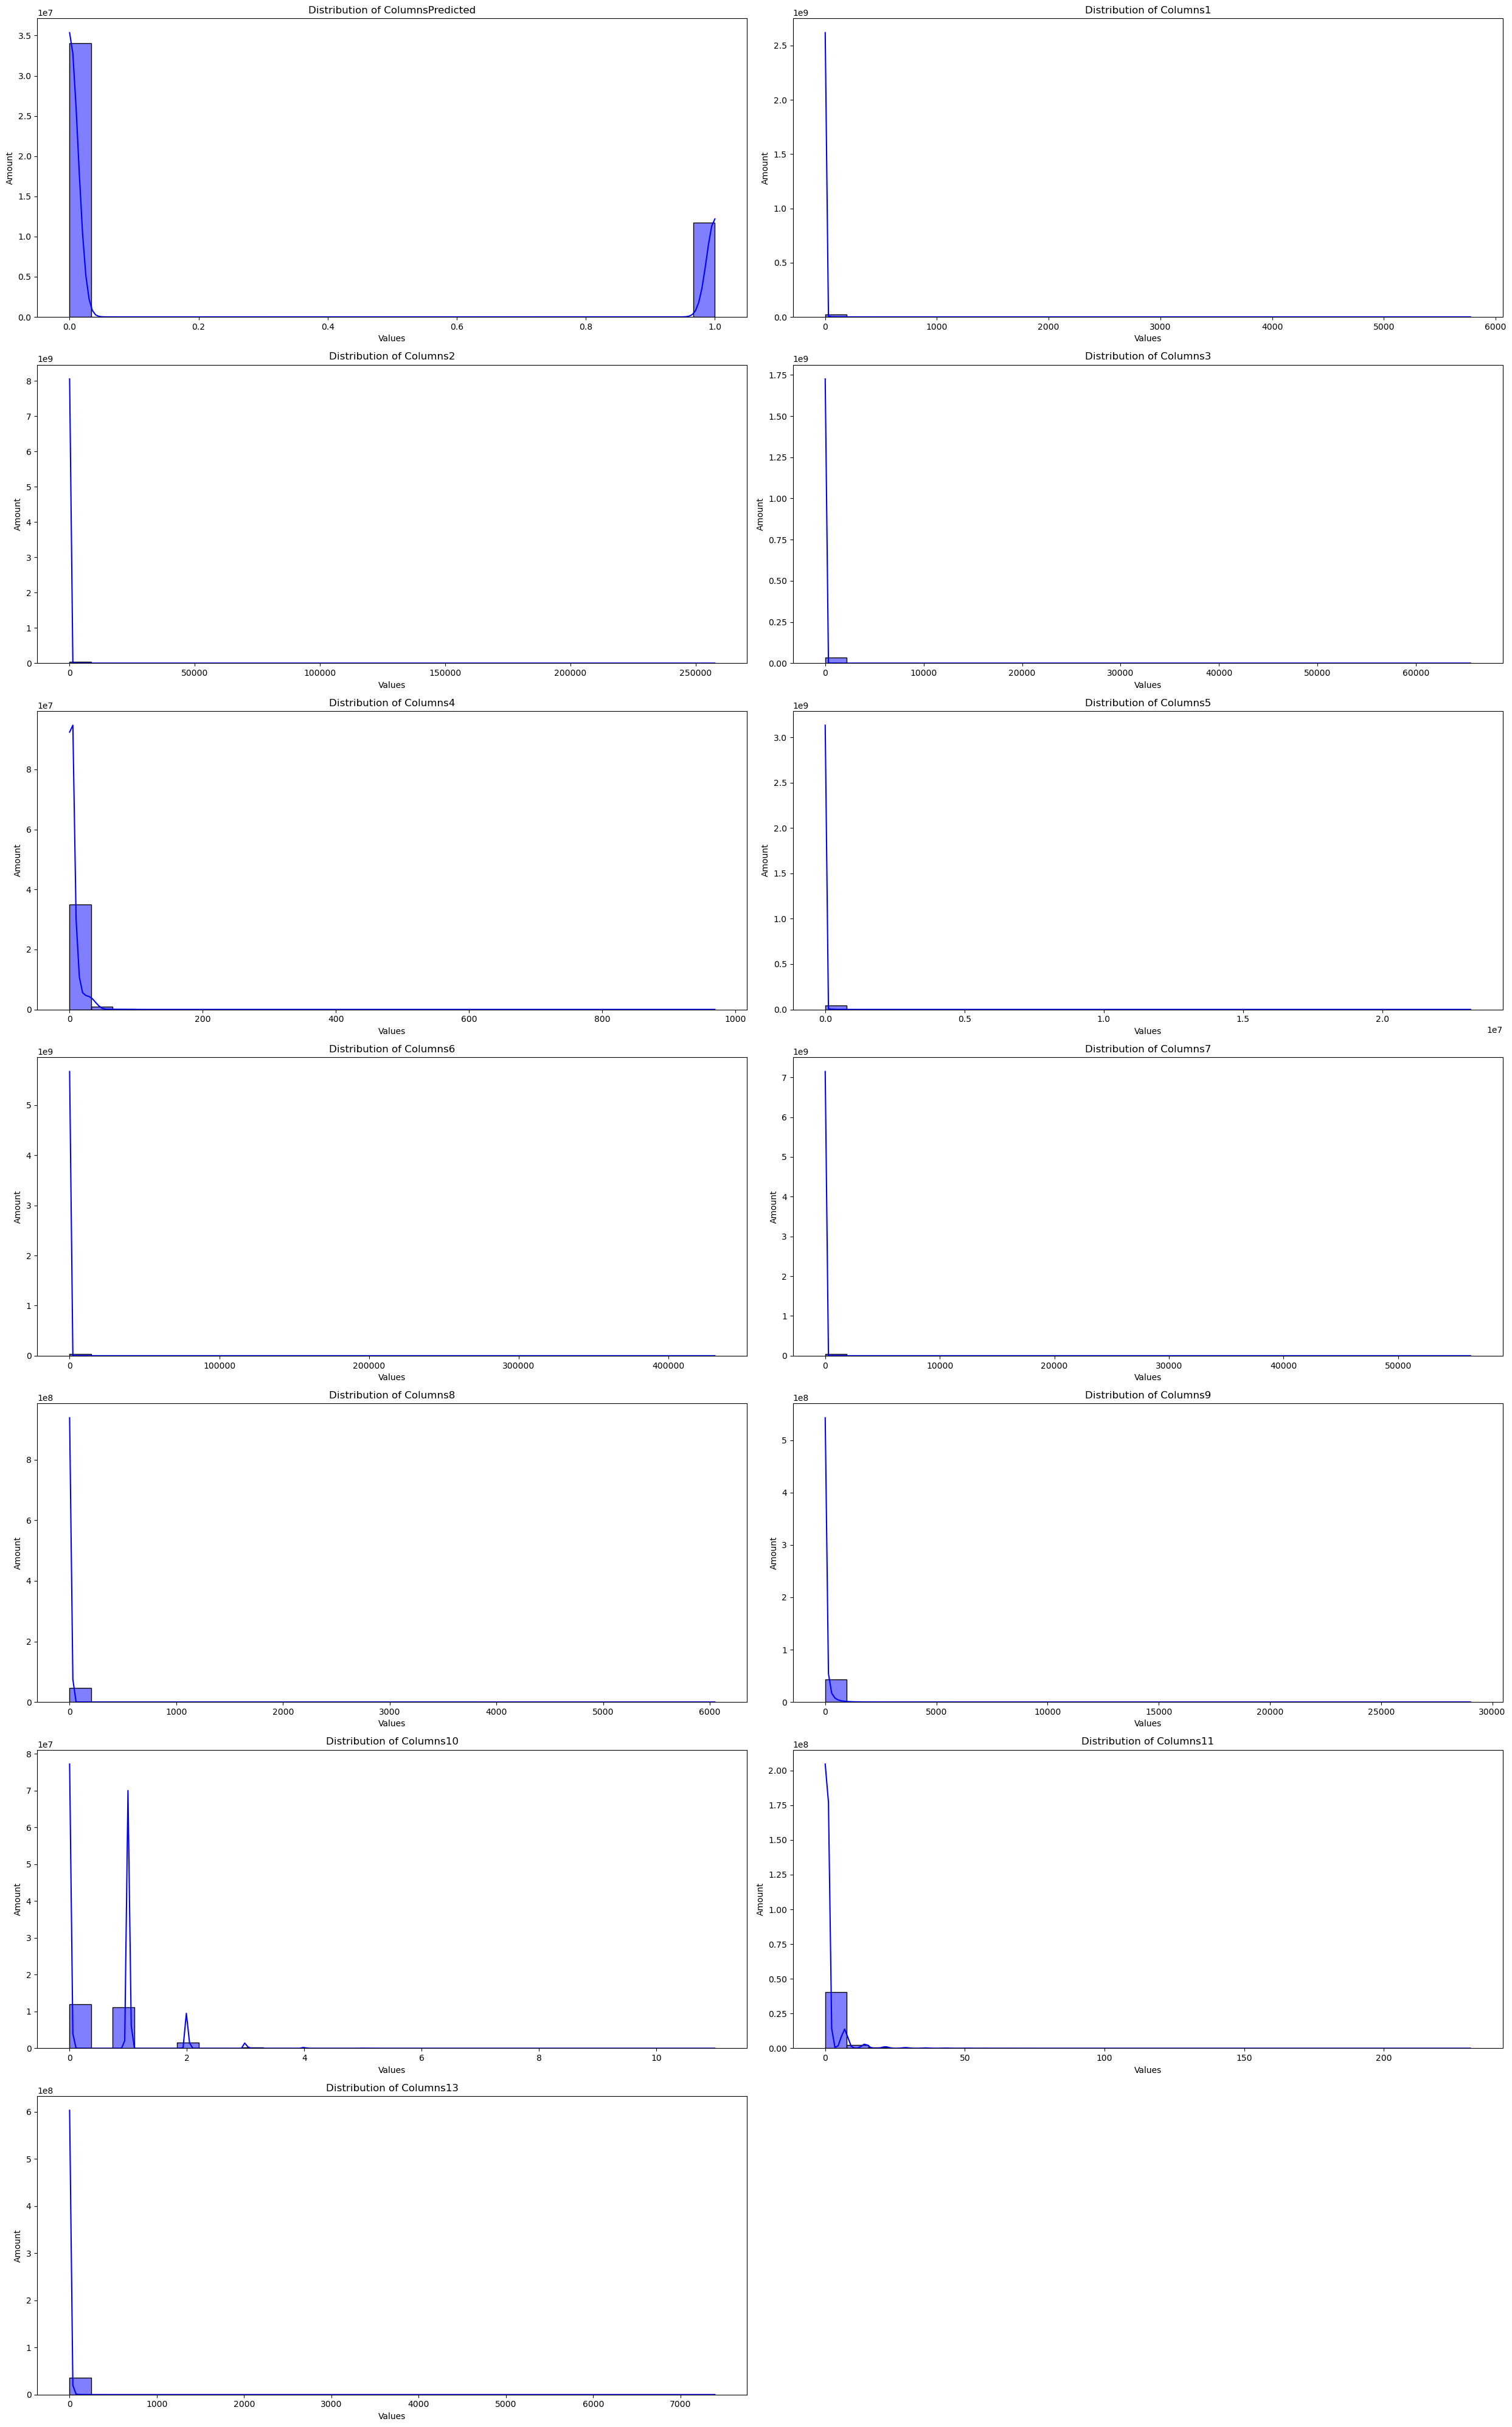

In [19]:
# 觀察數值型資料分佈
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(25, 40))

for i, col in enumerate(numerical_df):
    plt.subplot(7, 2, i+1)
    sns.histplot(numerical_df[col], bins=30, kde=True, color='blue')
    plt.title(f'Distribution of Columns{col}')
    plt.xlabel('Values')
    plt.ylabel('Amount')

plt.tight_layout()
plt.show()

In [20]:
# 計算每個欄位中的眾數、中位數、平均值
for col in numerical_df.loc[:, 'Predicted':'13'].columns:
  
    col_mode = numerical_df[col].dropna().mode()
    col_median = numerical_df[col].median()    
    col_avg = numerical_df[col].mean()

    print(f'Columns: {col}')
    print(f'Mode: {col_mode}')
    print(f'Median: {col_median}')
    print(f'AVG: {col_avg}\n')

Columns: Predicted
Mode: 0    0
Name: Predicted, dtype: int64
Median: 0.0
AVG: 0.2562526286022693

Columns: 1
Mode: 0   0.000
Name: 1, dtype: float64
Median: 1.0
AVG: 3.502406895254841

Columns: 2
Mode: 0    0
Name: 2, dtype: int64
Median: 3.0
AVG: 105.87165870626347

Columns: 3
Mode: 0   1.000
Name: 3, dtype: float64
Median: 6.0
AVG: 26.91484445574881

Columns: 4
Mode: 0   1.000
Name: 4, dtype: float64
Median: 4.0
AVG: 7.322787810906237

Columns: 5
Mode: 0   1.000
Name: 5, dtype: float64
Median: 2813.0
AVG: 18539.009129721697

Columns: 6
Mode: 0   0.000
Name: 6, dtype: float64
Median: 32.0
AVG: 116.06194009065553

Columns: 7
Mode: 0   0.000
Name: 7, dtype: float64
Median: 3.0
AVG: 16.333957580487077

Columns: 8
Mode: 0   0.000
Name: 8, dtype: float64
Median: 7.0
AVG: 12.51952273800278

Columns: 9
Mode: 0   1.000
Name: 9, dtype: float64
Median: 38.0
AVG: 106.11528899160525

Columns: 10
Mode: 0   0.000
Name: 10, dtype: float64
Median: 1.0
AVG: 0.6175282740822277

Columns: 11
Mode: 0   1

In [21]:
# 填補缺失值，由於資料分佈皆為左偏分佈，若平均值大於中位數則填補中位數，保留分佈型態；反之，填補眾數維持資料型態
from sklearn.impute import SimpleImputer

imputer_mode = SimpleImputer(strategy='most_frequent')
imputer_median = SimpleImputer(strategy='median')

for col in numerical_df.columns:
    if numerical_df[col].mean() > numerical_df[col].median():
        numerical_df[[col]] = imputer_median.fit_transform(numerical_df[[col]])
    else:
        numerical_df[[col]] = imputer_mode.fit_transform(numerical_df[[col]])

In [22]:
print(numerical_df.isna().sum())

Predicted    0
1            0
2            0
3            0
4            0
5            0
6            0
7            0
8            0
9            0
10           0
11           0
13           0
dtype: int64


In [24]:
# %%
# numerical_df.to_csv('cleaned_numerical_df.csv', index=False)

### <span style="color:grey; font-weight:bold;">Handling Objective Missing Values</span>

In [5]:
# %%
objective_df = pd.read_csv('Objective Removed Duplicates Date.csv')

In [6]:
objective_df.head()

,14,15,16,17,18,19,20,21,22,23,...,30,31,32,33,34,35,36,37,38,39
0,68fd1e64,f0cf0024,6f67f7e5,41274cd7,25c83c98,fe6b92e5,922afcc0,0b153874,a73ee510,2b53e5fb,...,07c540c4,b04e4670,21ddcdc9,5840adea,60f6221e,NaN,3a171ecb,43f13e8b,e8b83407,731c3655
1,287e684f,0a519c5c,02cf9876,c18be181,25c83c98,7e0ccccf,c78204a1,0b153874,a73ee510,3b08e48b,...,8efede7f,3412118d,NaN,NaN,e587c466,ad3062eb,3a171ecb,3b183c5c,NaN,NaN
2,68fd1e64,2c16a946,a9a87e68,2e17d6f6,25c83c98,fe6b92e5,2e8a689b,0b153874,a73ee510,efea433b,...,1e88c74f,74ef3502,NaN,NaN,6b3a5ca6,NaN,3a171ecb,9117a34a,NaN,NaN
3,8cf07265,ae46a29d,c81688bb,f922efad,25c83c98,13718bbd,ad9fa255,0b153874,a73ee510,5282c137,...,1e88c74f,26b3c7a7,NaN,NaN,21c9516a,NaN,32c7478e,b34f3128,NaN,NaN
4,05db9164,6c9c9cf3,2730ec9c,5400db8b,43b19349,6f6d9be8,53b5f978,0b153874,a73ee510,3b08e48b,...,776ce399,92555263,NaN,NaN,242bb710,8ec974f4,be7c41b4,72c78f11,NaN,NaN


In [8]:
objective_df.isna().sum().sort_values(ascending=False)

35    34945902
39    20162841
38    20162841
33    20162841
32    20162841
19     5540014
29     1558826
16     1558826
17     1558826
37     1558826
34     1558826
25     1558826
36           0
31           0
30           0
14           0
28           0
15           0
26           0
24           0
23           0
22           0
21           0
20           0
18           0
27           0
dtype: int64

In [6]:
# 先將資料轉換成數字型態，避免進迴圈造成核心崩潰
from sklearn.preprocessing import LabelEncoder

encoder_dict = {}

for col in objective_df.columns:

    non_missing = objective_df[col].dropna()

    encoder = LabelEncoder()
    encoded_non_missing = encoder.fit_transform(non_missing)
    objective_df.loc[objective_df[col].notna(), col] = encoded_non_missing

    encoder_dict[col] = encoder

objective_df.head()

,14,15,16,17,18,19,20,21,22,23,...,30,31,32,33,34,35,36,37,38,39
0,629,553,4409721,560291,43,22,7171,24,2,15712,...,0,3822,274,0,2666300,NaN,3,75549,88,64075
1,228,28,110897,1665959,43,9,9707,24,2,21414,...,6,1104,NaN,NaN,6317568,11,3,65597,NaN,NaN
2,629,102,6715434,396035,43,22,2302,24,2,87459,...,1,2522,NaN,NaN,2949276,NaN,3,161784,NaN,NaN
3,820,414,7920483,2143589,43,1,8492,24,2,29958,...,1,828,NaN,NaN,929196,NaN,2,200218,NaN,NaN
4,31,247,1550302,722747,92,8,4150,24,2,21414,...,5,3170,NaN,NaN,994954,10,11,127990,NaN,NaN


In [8]:
objective_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45829965 entries, 0 to 45829964
Data columns (total 26 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   14      object
 1   15      object
 2   16      object
 3   17      object
 4   18      object
 5   19      object
 6   20      object
 7   21      object
 8   22      object
 9   23      object
 10  24      object
 11  25      object
 12  26      object
 13  27      object
 14  28      object
 15  29      object
 16  30      object
 17  31      object
 18  32      object
 19  33      object
 20  34      object
 21  35      object
 22  36      object
 23  37      object
 24  38      object
 25  39      object
dtypes: object(26)
memory usage: 8.9+ GB


In [ ]:
from sklearn.tree import DecisionTreeClassifier

encoder_dict = {}

missing_col = [
    col for col in objective_df.columns
    if objective_df[col].isna().sum() > 0 
]

def model_fillna(missing_dataframe):

    for col in missing_dataframe:
        df_missing = objective_df[objective_df[col].isna()]
        df_non_missing = objective_df[~objective_df[col].isna()]

        x_train = df_non_missing.drop(columns=[col])
        y_train = df_non_missing[col].astype(int)
        x_missing = df_missing.drop(columns=[col])

        model = DecisionTreeClassifier(random_state=42)
        model.fit(x_train, y_train)

        predicted = model.predict(x_missing)
        df_missing[col] = predicted

        objective_df.loc[df_missing.index, col] = df_missing[col]

    return objective_df

objective_fillna_df = model_fillna(missing_col)

In [ ]:
from scipy.stats import boxcox, skew
import numpy as np

for i, col in enumerate(df_train_rmvd.select_dtypes(include=(np.number))):
    original_skew = skew(df_train_rmvd[col])
    print(original_skew)

    log_transformed_data = np.log(df_train_rmvd[col]+1)
    log_skew = skew(log_transformed_data)

    boxcox_transformed_data, _ = boxcox(df_train_rmvd[col]+1)
    boxcox_skew = skew(boxcox_transformed_data)

In [ ]:
plt.figure(figsize=(30, 20))

for i, col in enumerate(df_train_rmvd.loc[:, '1':'13'].columns):
    plt.subplot(len(df_train_rmvd), 1, i+1)
    sns.boxplot(data=df_train_rmvd, y=col)
    plt.title(f'Boxplot of {col}')

plt.show()

In [18]:
# df_test.head(10)

In [19]:
# df_test.tail(10)

In [20]:
# df_test.info()

In [21]:
# df_test.describe()

In [22]:
# print(len(df_test))

In [23]:
# df_test.duplicated().sum()

In [24]:
# df_test.drop_duplicates(inplace=True)
# df_test.duplicated().sum()

In [25]:
# print(len(df_test))